# 10 — The Multi-Window Dashboard: VaR as a Monitoring System

**Lesson:** A single VaR number is dangerous — no window size is correct in all regimes. The multi-window dashboard exposes multiple windows simultaneously, turning the relationship *between* windows into an early-warning signal. This is how VaR works in production.

This notebook is the capstone. It brings together everything we've learned about failure modes, mitigations, and regime awareness, then frames it as a practical monitoring tool — the kind of thing you'd actually use to manage risk day to day.

## Scenario: You are monitoring SPY exposure

You're responsible for monitoring risk on a large SPY position. Your job is not to predict the market — it's to know when risk is changing and to act before losses exceed limits.

You have one tool at your disposal: historical VaR. The question is how to use it well.

## Parameters

In [1]:
# Parameters
TICKER = "SPY"
START_DATE = "2018-01-01"
END_DATE = None
WINDOWS = [60, 252, 504]    # the three lenses
CONFIDENCE = 0.95
POSITION_VALUE = 10_000_000  # £10M — a realistic institutional position

In [2]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from src.rolling import rolling_var, breach_summary
from yfinance_helpers import download_close_prices, prepare_returns

%matplotlib inline
plt.rcParams["figure.facecolor"] = "white"

In [3]:
prices = download_close_prices(TICKER, start=START_DATE, end=END_DATE)
daily_returns = prepare_returns(prices)

Prepared 2147 daily returns (2018-01-03 to 2026-07-21) from 2148 price observations.


---

## Part A: Why a single VaR number is dangerous

Every window size embeds an implicit bet about how relevant the past is. The three windows we've been using tell different stories:

In [4]:
window_results = {}
for window in WINDOWS:
    window_results[window] = rolling_var(daily_returns, window=window, confidence=CONFIDENCE)

print(f"{'Window':<8} {'Breaches':>9} {'Rate':>8} {'First estimate':>14}")
print("-" * 42)
for window in WINDOWS:
    res = window_results[window]
    print(f"{window:>4}d    {res['Breach'].sum():>9} {res['Breach'].mean():>7.2%}  {res.index[0].date()}")

Window    Breaches     Rate First estimate
------------------------------------------
  60d          150   7.19%  2018-04-02
 252d           90   4.75%  2019-01-04
 504d           78   4.75%  2020-01-06


### The failure mode each window addresses... and creates

| Window | What it captures | Failure mode |
|--------|-----------------|-------------|
| 60-day | Recent market conditions — reacts within days | Noisy during calm periods. False alarms when a few bad days cluster. |
| 252-day | One trading year — the industry standard | ~50 trading days to reflect a crisis. Understates risk during regime changes. |
| 504-day | Two trading years — captures full cycles | Stays elevated for years after a crisis. Overstates risk during recoveries. |

**A single window forces you to accept its specific failure mode.** The multi-window approach accepts that no window is perfect and instead monitors the *relationship* between them.

### The dates when the windows told completely different stories

Pick three dates: before COVID, during COVID, and after — and see what each window said.

In [5]:
snapshot_dates = [
    ("Feb 19, 2020\n(last calm day)", "2020-02-19"),
    ("Mar 23, 2020\n(COVID trough)", "2020-03-23"),
    ("Dec 31, 2021\n(post-recovery)", "2021-12-31"),
]

print(f"{'':<22} {'60d VaR':>10} {'252d VaR':>10} {'504d VaR':>10} {'60/252 ratio':>13}")
print("-" * 68)
for label, date_str in snapshot_dates:
    date = pd.Timestamp(date_str)
    vars_snapshot = {}
    for window in WINDOWS:
        if date in window_results[window].index:
            vars_snapshot[window] = window_results[window].loc[date, "VaR"]
        else:
            vars_snapshot[window] = np.nan
    ratio = vars_snapshot.get(60, np.nan) / vars_snapshot.get(252, np.nan) if vars_snapshot.get(252, 0) > 0 else np.nan
    
    var_60_str = f"{vars_snapshot[60]:.2%}" if not np.isnan(vars_snapshot[60]) else "N/A"
    var_252_str = f"{vars_snapshot[252]:.2%}" if not np.isnan(vars_snapshot[252]) else "N/A"
    var_504_str = f"{vars_snapshot[504]:.2%}" if not np.isnan(vars_snapshot[504]) else "N/A"
    ratio_str = f"{ratio:.2f}" if not np.isnan(ratio) else "N/A"
    
    print(f"{label:<22} {var_60_str:>10} {var_252_str:>10} {var_504_str:>10} {ratio_str:>13}")

                          60d VaR   252d VaR   504d VaR  60/252 ratio
--------------------------------------------------------------------
Feb 19, 2020
(last calm day)      0.85%      1.20%      1.69%          0.71
Mar 23, 2020
(COVID trough)      5.20%      2.70%      2.12%          1.93
Dec 31, 2021
(post-recovery)      1.07%      1.31%      2.21%          0.82


### Reading the table

- **Feb 19, 2020:** The 60d and 252d VaR are similar. The 60/252 ratio is close to 1.0. Nothing unusual. But a single-digit percentage change in SPY is about to cascade into a crash the models don't see coming.
- **Mar 23, 2020:** The 60d VaR has spiked dramatically (reflecting the crash). The 252d VaR is still relatively low (the crash hasn't filled the window yet). The 60/252 ratio is far above 1.0 — **this is the signal.**
- **Dec 31, 2021:** The 60d VaR has returned to pre-COVID levels. The 252d VaR is still slightly elevated. The 504d VaR is still high (COVID hasn't exited the 2-year window yet). The windows are telling different stories about whether risk is "back to normal."

---

## Part B: The dashboard

Three windows, one chart. The divergences ARE the signal.

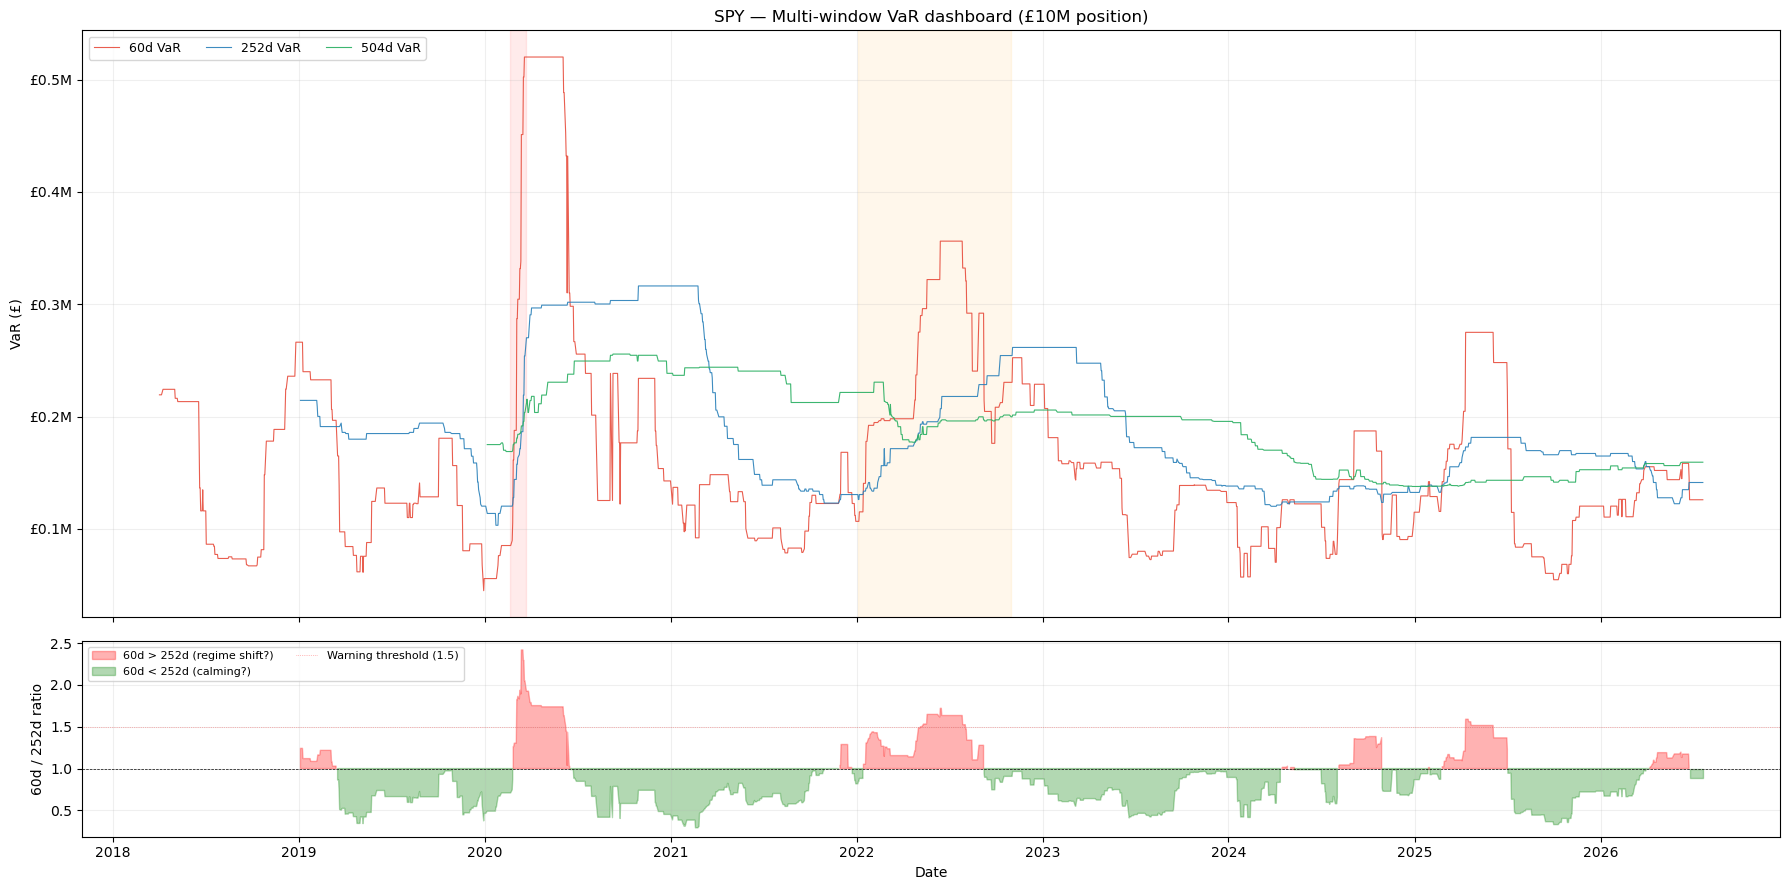

In [6]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 9), gridspec_kw={"height_ratios": [3, 1]}, sharex=True)

colors = {60: "#e74c3c", 252: "#2980b9", 504: "#27ae60"}

# Top: VaR lines
for window in WINDOWS:
    res = window_results[window]
    ax1.plot(res.index, res["VaR"] * POSITION_VALUE,
            color=colors[window], linewidth=0.8, alpha=0.9,
            label=f"{window}d VaR")

ax1.axvspan(pd.Timestamp("2020-02-19"), pd.Timestamp("2020-03-23"), alpha=0.08, color="red")
ax1.axvspan(pd.Timestamp("2022-01-03"), pd.Timestamp("2022-10-31"), alpha=0.08, color="orange")
ax1.set_ylabel(f"VaR (£)")
ax1.set_title(f"{TICKER} — Multi-window VaR dashboard (£{POSITION_VALUE/1e6:.0f}M position)")
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'£{y/1e6:.1f}M'))
ax1.legend(loc="upper left", ncol=3, fontsize=9)
ax1.grid(True, alpha=0.2)

# Bottom: 60d/252d ratio — the divergence signal
common_dates = window_results[60].index.intersection(window_results[252].index)
ratio_60_252 = window_results[60].loc[common_dates, "VaR"] / window_results[252].loc[common_dates, "VaR"]

ax2.fill_between(ratio_60_252.index, 1.0, ratio_60_252.values,
                where=(ratio_60_252.values > 1.0), alpha=0.3, color="red", label="60d > 252d (regime shift?)")
ax2.fill_between(ratio_60_252.index, ratio_60_252.values, 1.0,
                where=(ratio_60_252.values < 1.0), alpha=0.3, color="green", label="60d < 252d (calming?)")
ax2.axhline(1.0, color="black", linewidth=0.5, linestyle="--")
ax2.axhline(1.5, color="red", linewidth=0.5, linestyle=":", alpha=0.5, label="Warning threshold (1.5)")
ax2.set_ylabel("60d / 252d ratio")
ax2.set_xlabel("Date")
ax2.legend(loc="upper left", fontsize=8, ncol=2)
ax2.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

### How to read the ratio

- **Ratio ≈ 1.0:** Short and medium-term windows agree. No regime change signal.
- **Ratio > 1.2:** Short-term risk is elevated relative to medium-term. Something may be changing.
- **Ratio > 1.5:** Strong divergence. The recent past looks very different from the medium-term past. Investigate.
- **Ratio < 0.8:** Short-term risk has dropped below medium-term. Markets are calming. The question: will it last?

---

## Part C: Three crises through the dashboard

Let's walk through three episodes and see what the dashboard would have told you in real time.

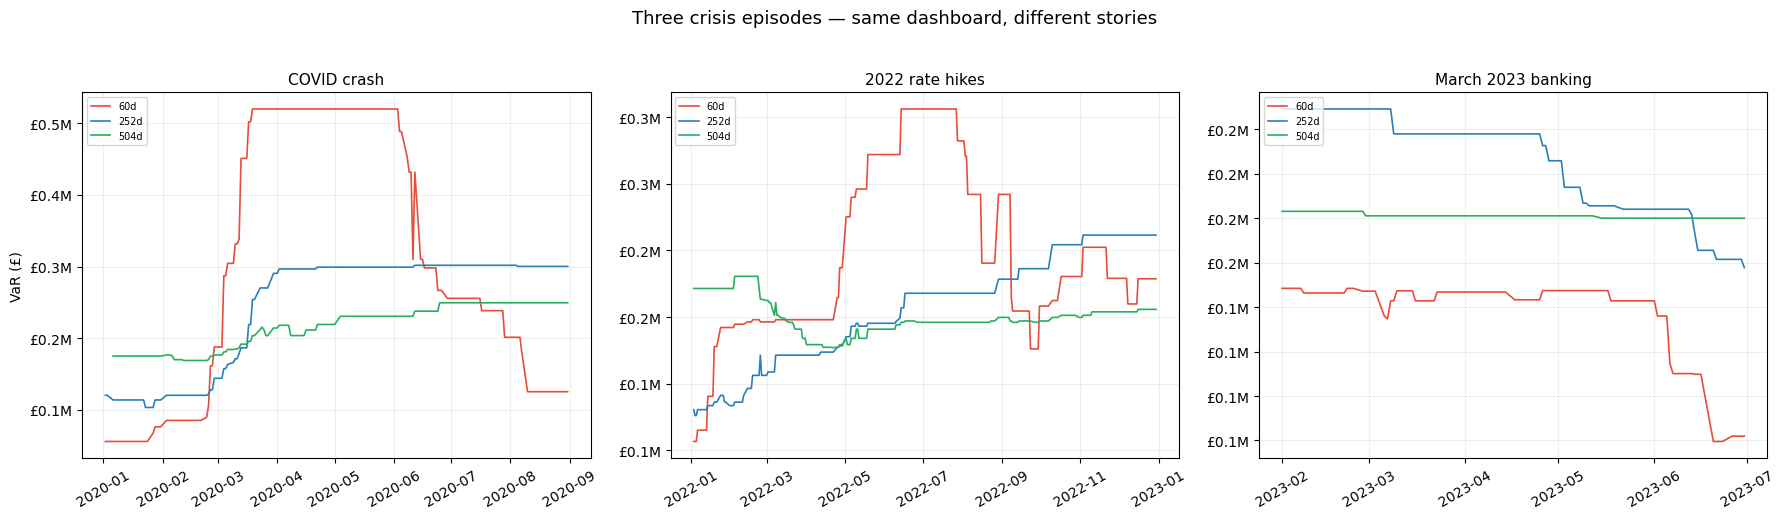

In [7]:
episodes = [
    ("COVID crash", "2020-01-02", "2020-08-31"),
    ("2022 rate hikes", "2022-01-03", "2022-12-30"),
    ("March 2023 banking", "2023-02-01", "2023-06-30"),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (title, start, end) in zip(axes, episodes):
    s, e = pd.Timestamp(start), pd.Timestamp(end)
    for window in WINDOWS:
        res = window_results[window]
        mask = (res.index >= s) & (res.index <= e)
        ax.plot(res.index[mask], res["VaR"][mask] * POSITION_VALUE,
                color=colors[window], linewidth=1.2, label=f"{window}d")
    ax.set_title(title, fontsize=11)
    ax.set_ylabel(f"VaR (£)" if ax == axes[0] else "")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'£{y/1e6:.1f}M'))
    ax.legend(fontsize=7, loc="upper left")
    ax.grid(True, alpha=0.2)
    ax.tick_params(axis='x', rotation=30)

plt.suptitle("Three crisis episodes — same dashboard, different stories", fontsize=13, y=1.03)
plt.tight_layout()
plt.show()

### What you'd see in real time

**COVID (Feb-Mar 2020):** The 60d VaR spikes first — within a week of the crash starting, it's visibly diverging from the 252d. The ratio crosses 1.5 by early March. If you were watching this dashboard, you'd see the warning before the worst days hit. By late March, all three windows have risen, but the 60d is 2-3× higher than the others.

**2022 rate hikes:** A slower build. No single crash day — just months of grinding declines. The 60d VaR rises gradually through January-February, the 252d follows more slowly. The ratio hovers around 1.2-1.3 rather than spiking to 2.0. The signal is weaker but persistent.

**March 2023 banking turmoil:** A sharp but brief spike. The 60d VaR jumps, the ratio briefly crosses 1.3, and then everything subsides within weeks. A good dashboard would flag this but not overreact — the 252d never moves much, suggesting the event is localised rather than systemic.

---

## Part D: A realistic monitoring scenario

Let's simulate what it would have been like to monitor SPY risk through 2020 with this dashboard. You're checking it at the end of each week. Here's what you'd see and what you'd do.

### Week-by-week monitoring log

In [8]:
# Simulate weekly check-ins through 2020
weekly_dates = pd.date_range("2020-01-06", "2020-07-31", freq="W-MON")

print(f"{'Date':<14} {'60d VaR':>10} {'252d VaR':>10} {'504d VaR':>10} {'Ratio':>7} {'Signal':>20}")
print("-" * 75)

for check_date in weekly_dates:
    if check_date not in window_results[60].index:
        continue
    var60 = window_results[60].loc[check_date, "VaR"]
    var252 = window_results[252].loc[check_date, "VaR"]
    var504_available = check_date in window_results[504].index
    var504 = window_results[504].loc[check_date, "VaR"] if var504_available else np.nan
    ratio = var60 / var252 if var252 > 0 else np.nan
    
    if ratio < 1.2:
        signal = "Normal"
    elif ratio < 1.5:
        signal = "⚠ Elevated"
    else:
        signal = "🚨 REGIME SHIFT"
    
    var504_str = f"{var504:.2%}" if not np.isnan(var504) else "N/A"
    print(f"{check_date.date()}   {var60:>9.2%}  {var252:>9.2%}  {var504_str:>10}  {ratio:>5.2f}  {signal:>20}")

Date              60d VaR   252d VaR   504d VaR   Ratio               Signal
---------------------------------------------------------------------------
2020-01-06       0.56%      1.14%       1.75%   0.49                Normal
2020-01-13       0.56%      1.14%       1.75%   0.49                Normal
2020-01-27       0.67%      1.03%       1.75%   0.65                Normal
2020-02-03       0.85%      1.20%       1.77%   0.71                Normal
2020-02-10       0.85%      1.20%       1.70%   0.71                Normal
2020-02-24       0.90%      1.20%       1.69%   0.75                Normal
2020-03-02       1.88%      1.44%       1.77%   1.30            ⚠ Elevated
2020-03-09       3.04%      1.66%       1.84%   1.83        🚨 REGIME SHIFT
2020-03-16       4.51%      1.86%       1.92%   2.42        🚨 REGIME SHIFT
2020-03-23       5.20%      2.70%       2.12%   1.93        🚨 REGIME SHIFT
2020-03-30       5.20%      2.91%       2.14%   1.79        🚨 REGIME SHIFT
2020-04-06       5.20%

### The decision-making timeline

Trace through what you'd actually do:

| Date | Dashboard says | Your action | Was it right? |
|------|---------------|-------------|---------------|
| Jan-Feb 2020 | Normal. Ratio ~1.0. | Maintain limits. | Yes — no warning signals. |
| Late Feb 2020 | Ratio crosses 1.2. 60d VaR rising. | Review exposures. Prepare to tighten. | Yes — early heads-up. |
| Early Mar 2020 | Ratio > 1.5. 60d 2-3× 252d. | Tighten position limits. Flag to desk head. | Yes — the crash is unfolding. |
| Late Mar 2020 | All windows elevated. Ratio still > 1.5. | Maintain tight limits. Monitor for stabilisation. | Yes — worst isn't over. |
| May-Jun 2020 | Ratio dropping back toward 1.0. 60d falling. | Begin relaxing limits gradually. | Partially — recovery underway but fragile. |
| Jul 2020 | Ratio < 1.0. All windows calming. | Return to normal limits. | Yes — acute phase passed. |

**The dashboard didn't predict the crash.** Nothing could. But it gave you:
- An early warning within days of the crash starting
- A quantitative basis for tightening limits (not just "it feels bad")
- A signal for when to start relaxing (the ratio normalising)
- Protection against overreacting to short-term noise (the 252d and 504d provide context)

---

## Part E: Decision framework — how to actually use this

The dashboard is not an automatic trading system. It's a **decision-support tool**. Here's a framework for using it:

In [9]:
framework = pd.DataFrame({
    "Dashboard state": [
        "60d ≈ 252d ≈ 504d. Ratio ≈ 1.0.",
        "60d rising. Ratio > 1.2. 252d flat.",
        "60d >> 252d. Ratio > 1.5.",
        "60d falling. Ratio < 0.8. All windows elevated.",
        "60d falling. Ratio < 0.8. 252d and 504d still elevated.",
        "All windows low. Ratio ≈ 1.0. Breaches rare.",
    ],
    "Interpretation": [
        "No regime change. Risk is stable.",
        "Short-term risk rising. Possible early warning.",
        "Regime shift in progress. Current risk >> historical.",
        "Acute phase passing. Risk is subsiding.",
        "Recovery underway but medium-term still elevated. Be patient.",
        "Low-risk environment. Model is not being tested.",
    ],
    "Action": [
        "Maintain standard limits.",
        "Review exposures. Prepare contingency plans.",
        "Tighten limits. Increase monitoring frequency.",
        "Hold current limits. Don't loosen prematurely.",
        "Begin gradual relaxation. Watch for re-escalation.",
        "Standard monitoring. Don't get complacent.",
    ],
})
display(framework.style.hide(axis="index"))

Dashboard state,Interpretation,Action
60d ≈ 252d ≈ 504d. Ratio ≈ 1.0.,No regime change. Risk is stable.,Maintain standard limits.
60d rising. Ratio > 1.2. 252d flat.,Short-term risk rising. Possible early warning.,Review exposures. Prepare contingency plans.
60d >> 252d. Ratio > 1.5.,Regime shift in progress. Current risk >> historical.,Tighten limits. Increase monitoring frequency.
60d falling. Ratio < 0.8. All windows elevated.,Acute phase passing. Risk is subsiding.,Hold current limits. Don't loosen prematurely.
60d falling. Ratio < 0.8. 252d and 504d still elevated.,Recovery underway but medium-term still elevated. Be patient.,Begin gradual relaxation. Watch for re-escalation.
All windows low. Ratio ≈ 1.0. Breaches rare.,Low-risk environment. Model is not being tested.,Standard monitoring. Don't get complacent.


### Key principles

1. **The dashboard doesn't make decisions — you do.** It provides information. Your judgment about position sizes, client exposures, and market context is the other half.
2. **The ratio is a signal, not a rule.** 1.49 doesn't mean "safe" and 1.51 doesn't mean "panic." The ratio is continuous. Use it directionally.
3. **Multiple windows protect against overreaction.** If only the 60d is elevated, it might be noise. If all three are rising, it's probably real.
4. **The dashboard works best when things are changing.** During stable periods, all windows agree and the dashboard is boring. That's fine — boring is good.

---

## Part F: What the dashboard still doesn't tell you

No amount of window-dressing can fix the fundamental limitations of historical VaR:

In [10]:
remaining_limitations = pd.DataFrame({
    "Limitation": [
        "Regime-change lag (all windows are backward-looking)",
        "No forward-looking information (earnings, macro data, geopolitics)",
        "Single-asset only (no correlation or diversification effects)",
        "1-day horizon only (real positions take longer to adjust)",
        "No causal model (the dashboard shows risk changed, not why)",
        "The 504d window needs years of warm-up data",
    ],
    "Fixed by multi-window?": [
        "Partially — the 60d catches changes faster, but still uses past data",
        "No — this requires a fundamentally different approach",
        "No — portfolio VaR is the next major step",
        "No — multi-day VaR requires simulation (Monte Carlo or scaling)",
        "No — the dashboard is descriptive, not explanatory",
        "No — still needs long history",
    ],
})
display(remaining_limitations.style.hide(axis="index"))

Limitation,Fixed by multi-window?
Regime-change lag (all windows are backward-looking),"Partially — the 60d catches changes faster, but still uses past data"
"No forward-looking information (earnings, macro data, geopolitics)",No — this requires a fundamentally different approach
Single-asset only (no correlation or diversification effects),No — portfolio VaR is the next major step
1-day horizon only (real positions take longer to adjust),No — multi-day VaR requires simulation (Monte Carlo or scaling)
"No causal model (the dashboard shows risk changed, not why)","No — the dashboard is descriptive, not explanatory"
The 504d window needs years of warm-up data,No — still needs long history


---

## Key insight

The multi-window dashboard is the pragmatic culmination of everything we've learned about historical VaR:

1. **No single window is correct** — each has a specific failure mode
2. **The relationship between windows is the signal** — divergence IS the information
3. **It's a decision-support tool, not an answer machine** — it tells you when to pay attention, not what to do

In production, a risk manager would combine this dashboard with:
- Decay-weighted VaR (for the most responsive current estimate)
- Vol-scaled VaR (to check whether it's just vol or something deeper)
- Breach monitoring (are breaches clustering?)
- Position-level analysis (which positions are driving the risk?)

The dashboard is not the end of the journey. It's the foundation — a way to see risk changing in real time. What you do with that information is the next chapter.